# Import Dataset

In [1]:
!pip install category_encoders

In [2]:
import numpy as np
import pandas as pd
import random
import time
import matplotlib.pyplot as plt
from sklearn.preprocessing import LabelEncoder
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from scipy.spatial.distance import cdist
from sklearn.cluster import KMeans
from yellowbrick.cluster import KElbowVisualizer
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler
import category_encoders as ce

# Load Dataset

In [3]:
df=pd.read_csv("ukmkuliner.csv",header=1)
df

,Usia,Jenis Kelamin,Pendidikan Terakhir,Provinsi,Kab/Kota,Kecamatan,"Desa/Kel, RT, RW",Nama Jalan,Nama Usaha,Tanggal Pendirian Usaha,...,Tujuan Pemasaran,Status Kepemilkan Tanah/Bangunan,Sarana Media Elektronik,Modal Bantuan Pemerintah,Pinjaman Kredit Usaha Rakyat,Omset per-Tahun,Kepemilikan Asuransi Kesehatan,Laki-laki,Perempuan,Rerata Usia Pekerja
0,41,P,SMA,DAERAH ISTIMEWA YOGYAKARTA,KOTA YOGYAKARTA,TEGALREJO,"KARANGAWARU, 21, 6",BLUNYAHREJO TR.II/839,NASYWA SNACK,24 Juli 2012,...,Dalam wilayah DIY,Lainnya,"WhatsApp, Facebook",-,-,Kurang dari 10 juta,-,0,0,-
1,53,P,SMA,DAERAH ISTIMEWA YOGYAKARTA,KOTA YOGYAKARTA,DANUREJAN,"TEGALPANGGUNG, 26, 5",TUKANGAN DN. 2/506,TUNGKU MA ENDANG,16 Februari 2016,...,"Dalam wilayah Kota Yogyakarta, Dalam wilayah D...",Milik sendiri,"WhatsApp, Instagram",Pemkot Yogyakarta,-,Kurang dari 10 juta,BPJS,0,2,35-50 tahun
2,45,P,0,DAERAH ISTIMEWA YOGYAKARTA,KOTA YOGYAKARTA,TEGALREJO,"KRICAK, 38, 8",KRICAK KIDUL TR.I/1130,JP CATERING,07 Januari 2022,...,Dalam wilayah Kota Yogyakarta,Lainnya,WhatsApp,Pemkot Yogyakarta,"Bank, Pemerintah",10 juta s/d 25 juta,-,1,1,35-50 tahun
3,40,L,SMA,DAERAH ISTIMEWA YOGYAKARTA,KOTA YOGYAKARTA,UMBULHARJO,"GIWANGAN, 12, 4",TEGAL TURI GIWANGAN UH 7/137,JUALAN ES KELAPA MUDA,22 Juni 2020,...,Dalam wilayah Kota Yogyakarta,Sewa,WhatsApp,Pemkot Yogyakarta,Lainnya,10 juta s/d 25 juta,BPJS,1,0,25-35 tahun
4,-,-,SMP,DI. YOGYAKARTA,KAB. GUNUNGKIDUL,KARANGMOJO,"KARANGMOJO, -, -",SUMBEREJO,ANGKRINGAN,04 Februari 2005,...,Dalam wilayah Kota Yogyakarta,Lainnya,Lainnya,Pemerintah Pusat,Lainnya,Kurang dari 10 juta,BPJS,0,0,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1331,46,L,-,DAERAH ISTIMEWA YOGYAKARTA,KOTA YOGYAKARTA,GONDOKUSUMAN,"KLITREN, 33, 8",IROMEJAN GK. 3 / 748,SEAFOOD BU PUJI,20 Agustus 1990,...,Dalam wilayah Kota Yogyakarta,Lainnya,WhatsApp,-,-,Kurang dari 10 juta,-,2,0,25-35 tahun
1332,43,L,SMA,DAERAH ISTIMEWA YOGYAKARTA,KOTA YOGYAKARTA,DANUREJAN,"BAUSASRAN, 16, 5",LEMPUYANGAN DN.3/349,THE LEGEND DONUT,26 Oktober 2011,...,Dalam wilayah Kota Yogyakarta,Milik sendiri,WhatsApp,-,-,10 juta s/d 25 juta,-,1,0,25-35 tahun
1333,47,P,S1,DAERAH ISTIMEWA YOGYAKARTA,KOTA YOGYAKARTA,TEGALREJO,"KARANGAWARU, 44, 12",BANGIREJO KW I/99,DAPUR NUGGETQU,09 September 2020,...,Dalam wilayah DIY,Milik sendiri,"WhatsApp, Facebook, Twitter, Instagram",-,-,Kurang dari 10 juta,BPJS,0,0,35-50 tahun
1334,36,L,SMK,DAERAH ISTIMEWA YOGYAKARTA,KOTA YOGYAKARTA,WIROBRAJAN,"PATANGPULUHAN, 17, 3",PATANGPULUHAN WB 3/400,YUYUN ES TEBU,07 September 2020,...,Dalam wilayah Kota Yogyakarta,Lainnya,-,-,Lainnya,Kurang dari 10 juta,BPJS,1,0,25-35 tahun


**Penjelasan Binary Encoding pada 'Sarana Media Elektronik'**

Binary Encoding adalah teknik untuk mengubah data kategorikal menjadi format numerik. Cara kerjanya adalah sebagai berikut:

1.  Setiap kategori unik dalam kolom asli diberi kode integer (dimulai dari 0).
2.  Kode integer ini kemudian diubah menjadi representasi biner.
3.  Setiap bit dalam representasi biner tersebut dijadikan kolom terpisah dalam DataFrame baru.

Metode ini berguna ketika jumlah kategori unik dalam sebuah kolom sangat banyak, karena menghasilkan jumlah kolom yang lebih sedikit dibandingkan One-Hot Encoding.

**Contoh 5 Data Awal:**

Berikut adalah 5 data awal dari kolom 'Sarana Media Elektronik' (Asli) dan hasil Binary Encoding-nya:

| Sarana Media Elektronik (Asli) | Sarana Media Elektronik_0 | Sarana Media Elektronik_1 | Sarana Media Elektronik_2 | Sarana Media Elektronik_3 | Sarana Media Elektronik_4 | Sarana Media Elektronik_5 | Sarana Media Elektronik_6 |
| :----------------------------- | :------------------------ | :------------------------ | :------------------------ | :------------------------ | :------------------------ | :------------------------ | :------------------------ |
| WhatsApp, Facebook             | 0                         | 0                         | 0                         | 0                         | 0                         | 1                         | 1                         |
| WhatsApp, Instagram            | 0                         | 0                         | 0                         | 0                         | 1                         | 0                         | 0                         |
| WhatsApp                       | 0                         | 0                         | 0                         | 0                         | 1                         | 0                         | 1                         |
| WhatsApp                       | 0                         | 0                         | 0                         | 0                         | 1                         | 0                         | 1                         |
| Lainnya                        | 0                         | 0                         | 0                         | 1                         | 0                         | 0                         | 0                         |

Setiap baris pada kolom biner (`Sarana Media Elektronik_0` sampai `_6`) secara unik merepresentasikan nilai asli di kolom pertama.

# Preprocessing & EDA

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1336 entries, 0 to 1335
Data columns (total 30 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Usia                              1336 non-null   object
 1   Jenis Kelamin                     1336 non-null   object
 2   Pendidikan Terakhir               1336 non-null   object
 3   Provinsi                          1335 non-null   object
 4   Kab/Kota                          1335 non-null   object
 5   Kecamatan                         1335 non-null   object
 6   Desa/Kel, RT, RW                  1336 non-null   object
 7   Nama Jalan                        1335 non-null   object
 8   Nama Usaha                        1336 non-null   object
 9   Tanggal Pendirian Usaha           1336 non-null   object
 10  Provinsi.1                        1336 non-null   object
 11  Kab/Kota.1                        1336 non-null   object
 12  Kecamatan.1         

In [5]:
df.isnull().sum()

Usia                                0
Jenis Kelamin                       0
Pendidikan Terakhir                 0
Provinsi                            1
Kab/Kota                            1
Kecamatan                           1
Desa/Kel, RT, RW                    0
Nama Jalan                          1
Nama Usaha                          0
Tanggal Pendirian Usaha             0
Provinsi.1                          0
Kab/Kota.1                          0
Kecamatan.1                         0
Desa/Kel, RT, RW.1                  0
Nama Jalan.1                        0
Koordinat                           0
Bidang Usaha                        0
Sektor Usaha                        0
Kegiatan Usaha                      0
Produk Komoditas Ekspor             0
Tujuan Pemasaran                    0
Status Kepemilkan Tanah/Bangunan    0
Sarana Media Elektronik             0
Modal Bantuan Pemerintah            0
Pinjaman Kredit Usaha Rakyat        0
Omset per-Tahun                     0
Kepemilikan 

In [6]:
df.duplicated().sum()

0

In [7]:
# Memilih kolom yang relevan untuk clustering
selected_columns = [
  "Omset per-Tahun",
    "Pendidikan Terakhir",
    "Status Kepemilkan Tanah/Bangunan",
    "Kepemilikan Asuransi Kesehatan",
    # "Sarana Media Elektronik",
    "Modal Bantuan Pemerintah",
    "Jenis Kelamin"

]
df_selected = df[selected_columns]

In [8]:
df_selected.head()

,Omset per-Tahun,Pendidikan Terakhir,Status Kepemilkan Tanah/Bangunan,Kepemilikan Asuransi Kesehatan,Modal Bantuan Pemerintah,Jenis Kelamin
0,Kurang dari 10 juta,SMA,Lainnya,-,-,P
1,Kurang dari 10 juta,SMA,Milik sendiri,BPJS,Pemkot Yogyakarta,P
2,10 juta s/d 25 juta,0,Lainnya,-,Pemkot Yogyakarta,P
3,10 juta s/d 25 juta,SMA,Sewa,BPJS,Pemkot Yogyakarta,L
4,Kurang dari 10 juta,SMP,Lainnya,BPJS,Pemerintah Pusat,-


In [9]:
df_selected.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1336 entries, 0 to 1335
Data columns (total 6 columns):
 #   Column                            Non-Null Count  Dtype 
---  ------                            --------------  ----- 
 0   Omset per-Tahun                   1336 non-null   object
 1   Pendidikan Terakhir               1336 non-null   object
 2   Status Kepemilkan Tanah/Bangunan  1336 non-null   object
 3   Kepemilikan Asuransi Kesehatan    1336 non-null   object
 4   Modal Bantuan Pemerintah          1336 non-null   object
 5   Jenis Kelamin                     1336 non-null   object
dtypes: object(6)
memory usage: 62.8+ KB


In [10]:
df_selected.describe(include="all")

,Omset per-Tahun,Pendidikan Terakhir,Status Kepemilkan Tanah/Bangunan,Kepemilikan Asuransi Kesehatan,Modal Bantuan Pemerintah,Jenis Kelamin
count,1336,1336,1336,1336,1336,1336
unique,10,17,4,4,4,3
top,Kurang dari 10 juta,SMA,Milik sendiri,BPJS,-,P
freq,860,377,693,920,909,952


## Jenis Kelamin

In [11]:
df["Jenis Kelamin"].value_counts()

Jenis Kelamin
P    952
L    330
-     54
Name: count, dtype: int64

In [12]:
Kelamin = {"-":2,"P": 1, "L": 0}
df_selected["Jenis Kelamin"] = df_selected["Jenis Kelamin"].map(Kelamin)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_5804\215224243.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected["Jenis Kelamin"] = df_selected["Jenis Kelamin"].map(Kelamin)


## Pendidikan Terakhir

In [13]:
df["Pendidikan Terakhir"].value_counts()

Pendidikan Terakhir
SMA                                 377
SMK                                 250
S1                                  194
-                                   172
SMP                                 137
SD                                   88
D3                                   78
D2                                    9
D1                                    9
S2                                    8
0                                     8
DIPLOMA IV/STRATA I                   1
SLTA/SEDERAJAT                        1
TAMAT SD/SEDERAJAT                    1
D4                                    1
BELUM TAMAT SD/SEDERAJAT              1
AKADEMI/DIPLOMA III/SARJANA MUDA      1
Name: count, dtype: int64

In [14]:
le = LabelEncoder()
df_selected["Pendidikan Terakhir"] = le.fit_transform(df_selected["Pendidikan Terakhir"] .astype(str))  # Memastikan tipe data string agar bisa dikodekan


C:\Users\ASUS\AppData\Local\Temp\ipykernel_5804\2630359316.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected["Pendidikan Terakhir"] = le.fit_transform(df_selected["Pendidikan Terakhir"] .astype(str))  # Memastikan tipe data string agar bisa dikodekan


## Status Kepemilikan tanah

In [15]:
le = LabelEncoder()
df_selected["Status Kepemilkan Tanah/Bangunan"] = le.fit_transform(df_selected["Status Kepemilkan Tanah/Bangunan"].astype(str))  # Pastikan tipe data string agar bisa dikodekan


C:\Users\ASUS\AppData\Local\Temp\ipykernel_5804\2495442931.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected["Status Kepemilkan Tanah/Bangunan"] = le.fit_transform(df_selected["Status Kepemilkan Tanah/Bangunan"].astype(str))  # Pastikan tipe data string agar bisa dikodekan


In [16]:
df["Status Kepemilkan Tanah/Bangunan"].value_counts()

Status Kepemilkan Tanah/Bangunan
Milik sendiri       693
Lainnya             314
Sewa                247
Magersari (adat)     82
Name: count, dtype: int64

## Sarana Media Eletronik

In [17]:
df["Sarana Media Elektronik"].value_counts()

Sarana Media Elektronik
WhatsApp                                        465
WhatsApp, Facebook, Instagram                   132
WhatsApp, Facebook                              109
WhatsApp, Instagram                              74
Lainnya                                          70
                                               ... 
WhatsApp, Instagram, Tokopedia                    1
WhatsApp, Facebook, Twitter, Instagram, Grab      1
WhatsApp, Grab, Lainnya                           1
Instagram, Shopee, Gojek, Grab                    1
WhatsApp, Instagram, Tokopedia, Gojek             1
Name: count, Length: 91, dtype: int64

In [18]:
# 3️⃣ Binary Encoding untuk 'Media Elektronik'
encoder = ce.BinaryEncoder(cols=["Sarana Media Elektronik"])
df_encoded = encoder.fit_transform(df[["Sarana Media Elektronik"]])



## Omset Pertahun

In [19]:
df["Omset per-Tahun"].value_counts()

Omset per-Tahun
Kurang dari 10 juta      860
10 juta s/d 25 juta      293
25 juta s/d 40 juta       73
40 juta s/d 55 juta       29
100 juta s/d 120 juta     19
Lebih dari 150 juta       16
85 juta s/d 100 juta      15
55 juta s/d 70 juta       15
120 juta s/d 150 juta      8
70 juta s/d 85 juta        8
Name: count, dtype: int64

In [20]:
omset_mapping = {
    "Kurang dari 10 juta": 5_000_000,   # (0 - 10 juta)
    "10 juta s/d 25 juta": 17_500_000,  # (10+25)/2 
    "25 juta s/d 40 juta": 32_500_000,  # (25+40)/2 
    "40 juta s/d 55 juta": 47_500_000,  # (40+55)/2 
    "55 juta s/d 70 juta": 62_500_000,  # (55+70)/2 
    "70 juta s/d 85 juta": 77_500_000,  # (70+85)/2 
    "85 juta s/d 100 juta": 92_500_000, # (85+100)/2 
    "100 juta s/d 120 juta": 110_000_000, # (100+120)/2 
    "120 juta s/d 150 juta": 135_000_000, # (120+150)/2 
    "Lebih dari 150 juta": 175_000_000  #  diambil 175 
}
df_selected["Omset per-Tahun"] = df_selected["Omset per-Tahun"].map(omset_mapping)

C:\Users\ASUS\AppData\Local\Temp\ipykernel_5804\1943329146.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected["Omset per-Tahun"] = df_selected["Omset per-Tahun"].map(omset_mapping)


## Kepemilikan Asuransi

In [21]:
df["Kepemilikan Asuransi Kesehatan"].value_counts()

Kepemilikan Asuransi Kesehatan
BPJS                     920
-                        404
Asuransi Swasta            8
BPJS, Asuransi Swasta      4
Name: count, dtype: int64

In [22]:
le = LabelEncoder()
df_selected["Kepemilikan Asuransi Kesehatan"] = le.fit_transform(df_selected["Kepemilikan Asuransi Kesehatan"].astype(str))  # Pastikan tipe data string agar bisa dikodekan


C:\Users\ASUS\AppData\Local\Temp\ipykernel_5804\2372082381.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected["Kepemilikan Asuransi Kesehatan"] = le.fit_transform(df_selected["Kepemilikan Asuransi Kesehatan"].astype(str))  # Pastikan tipe data string agar bisa dikodekan


## Modal Bantuan Pemerintah

In [23]:
df["Modal Bantuan Pemerintah"].value_counts()

Modal Bantuan Pemerintah
-                    909
Pemerintah Pusat     255
Pemkot Yogyakarta    140
Pemda DIY             32
Name: count, dtype: int64

In [24]:
le = LabelEncoder()
df_selected["Modal Bantuan Pemerintah"] = le.fit_transform(df_selected["Modal Bantuan Pemerintah"].astype(str))  # Pastikan tipe data string agar bisa dikodekan


C:\Users\ASUS\AppData\Local\Temp\ipykernel_5804\1542393778.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_selected["Modal Bantuan Pemerintah"] = le.fit_transform(df_selected["Modal Bantuan Pemerintah"].astype(str))  # Pastikan tipe data string agar bisa dikodekan


# Hasil Preprocessing

**Penjelasan Binary Encoding pada 'Sarana Media Elektronik'**

Binary Encoding adalah teknik untuk mengubah data kategorikal menjadi format numerik. Cara kerjanya adalah sebagai berikut:

1.  Setiap kategori unik dalam kolom asli diberi kode integer (dimulai dari 0).
2.  Kode integer ini kemudian diubah menjadi representasi biner.
3.  Setiap bit dalam representasi biner tersebut dijadikan kolom terpisah dalam DataFrame baru.

Metode ini berguna ketika jumlah kategori unik dalam sebuah kolom sangat banyak, karena menghasilkan jumlah kolom yang lebih sedikit dibandingkan One-Hot Encoding.

**Contoh 5 Data Awal:**

Berikut adalah 5 data awal dari kolom 'Sarana Media Elektronik' (Asli) dan hasil Binary Encoding-nya:

| Sarana Media Elektronik (Asli) | Sarana Media Elektronik_0 | Sarana Media Elektronik_1 | Sarana Media Elektronik_2 | Sarana Media Elektronik_3 | Sarana Media Elektronik_4 | Sarana Media Elektronik_5 | Sarana Media Elektronik_6 |
| :----------------------------- | :------------------------ | :------------------------ | :------------------------ | :------------------------ | :------------------------ | :------------------------ | :------------------------ |
| WhatsApp, Facebook             | 0                         | 0                         | 0                         | 0                         | 0                         | 1                         | 1                         |
| WhatsApp, Instagram            | 0                         | 0                         | 0                         | 0                         | 1                         | 0                         | 0                         |
| WhatsApp                       | 0                         | 0                         | 0                         | 0                         | 1                         | 0                         | 1                         |
| WhatsApp                       | 0                         | 0                         | 0                         | 0                         | 1                         | 0                         | 1                         |
| Lainnya                        | 0                         | 0                         | 0                         | 1                         | 0                         | 0                         | 0                         |

Setiap baris pada kolom biner (`Sarana Media Elektronik_0` sampai `_6`) secara unik merepresentasikan nilai asli di kolom pertama.

In [25]:
df_encoded.value_counts()

Sarana Media Elektronik_0  Sarana Media Elektronik_1  Sarana Media Elektronik_2  Sarana Media Elektronik_3  Sarana Media Elektronik_4  Sarana Media Elektronik_5  Sarana Media Elektronik_6
0                          0                          0                          0                          0                          1                          1                            465
                                                                                 1                          0                          0                          1                            132
                                                                                 0                          0                          0                          1                            109
                                                                                                                                       1                          0                             74
                                

In [26]:
df_encoded

,Sarana Media Elektronik_0,Sarana Media Elektronik_1,Sarana Media Elektronik_2,Sarana Media Elektronik_3,Sarana Media Elektronik_4,Sarana Media Elektronik_5,Sarana Media Elektronik_6
0,0,0,0,0,0,0,1
1,0,0,0,0,0,1,0
2,0,0,0,0,0,1,1
3,0,0,0,0,0,1,1
4,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...
1331,0,0,0,0,0,1,1
1332,0,0,0,0,0,1,1
1333,0,0,1,1,0,1,0
1334,0,0,0,1,0,1,1


Berikut adalah ringkasan transformasi yang dilakukan pada data:

| Kolom                              | Transformasi         | Penjelasan                                                                                                | Sebelum                 | Setelah (Contoh) |
| :--------------------------------- | :------------------- | :-------------------------------------------------------------------------------------------------------- | :---------------------- | :--------------- |
| Jenis Kelamin                      | Pemetaan Manual      | Mengubah teks menjadi angka berdasarkan pemetaan tetap.                                                   | P, L, -                 | 1, 0, 2          |
| Pendidikan Terakhir                | Label Encoding       | Memberikan label numerik unik untuk setiap kategori pendidikan.                                           | SMA, S1, SMP, ...       | 13, 9, 15, ...   |
| Status Kepemilkan Tanah/Bangunan   | Label Encoding       | Memberikan label numerik unik untuk setiap status kepemilikan.                                            | Milik sendiri, Sewa,... | 2, 3, ...        |
| Kepemilikan Asuransi Kesehatan     | Label Encoding       | Memberikan label numerik unik untuk setiap jenis asuransi kesehatan.                                      | BPJS, -, ...            | 2, 0, ...        |
| Modal Bantuan Pemerintah           | Label Encoding       | Memberikan label numerik unik untuk setiap sumber modal bantuan.                                          | -, Pemerintah Pusat,... | 0, 2, ...        |
| Omset per-Tahun                    | Pemetaan Manual      | Mengganti rentang teks dengan nilai numerik perkiraan omset.                                              | Kurang dari 10 juta,... | 5000000,...      |
| Sarana Media Elektronik            | Binary Encoding      | Mengubah setiap kategori unik menjadi representasi biner, dengan setiap bit menjadi kolom terpisah.       | WhatsApp, ...           | Sarana Media Elektronik_0, ... |

In [27]:
df_selected

,Omset per-Tahun,Pendidikan Terakhir,Status Kepemilkan Tanah/Bangunan,Kepemilikan Asuransi Kesehatan,Modal Bantuan Pemerintah,Jenis Kelamin
0,5000000,13,0,0,0,1
1,5000000,13,2,2,3,1
2,17500000,1,0,0,3,1
3,17500000,13,3,2,3,0
4,5000000,15,0,2,2,2
...,...,...,...,...,...,...
1331,5000000,0,0,0,0,0
1332,17500000,13,2,0,0,0
1333,5000000,9,2,2,0,1
1334,5000000,14,0,2,0,0


In [28]:
df_selected.describe(include="all")

,Omset per-Tahun,Pendidikan Terakhir,Status Kepemilkan Tanah/Bangunan,Kepemilikan Asuransi Kesehatan,Modal Bantuan Pemerintah,Jenis Kelamin
count,1.336000e+03,1336.000000,1336.000000,1336.000000,1336.000000,1336.000000
mean,1.653630e+07,10.370509,1.653443,1.392216,0.720060,0.793413
std,2.721984e+07,4.797596,1.032993,0.921844,1.101345,0.494904
min,5.000000e+06,0.000000,0.000000,0.000000,0.000000,0.000000
25%,5.000000e+06,9.000000,1.000000,0.000000,0.000000,1.000000
50%,5.000000e+06,13.000000,2.000000,2.000000,0.000000,1.000000
75%,1.750000e+07,14.000000,2.000000,2.000000,2.000000,1.000000
max,1.750000e+08,16.000000,3.000000,3.000000,3.000000,2.000000


In [29]:
df

,Usia,Jenis Kelamin,Pendidikan Terakhir,Provinsi,Kab/Kota,Kecamatan,"Desa/Kel, RT, RW",Nama Jalan,Nama Usaha,Tanggal Pendirian Usaha,...,Tujuan Pemasaran,Status Kepemilkan Tanah/Bangunan,Sarana Media Elektronik,Modal Bantuan Pemerintah,Pinjaman Kredit Usaha Rakyat,Omset per-Tahun,Kepemilikan Asuransi Kesehatan,Laki-laki,Perempuan,Rerata Usia Pekerja
0,41,P,SMA,DAERAH ISTIMEWA YOGYAKARTA,KOTA YOGYAKARTA,TEGALREJO,"KARANGAWARU, 21, 6",BLUNYAHREJO TR.II/839,NASYWA SNACK,24 Juli 2012,...,Dalam wilayah DIY,Lainnya,"WhatsApp, Facebook",-,-,Kurang dari 10 juta,-,0,0,-
1,53,P,SMA,DAERAH ISTIMEWA YOGYAKARTA,KOTA YOGYAKARTA,DANUREJAN,"TEGALPANGGUNG, 26, 5",TUKANGAN DN. 2/506,TUNGKU MA ENDANG,16 Februari 2016,...,"Dalam wilayah Kota Yogyakarta, Dalam wilayah D...",Milik sendiri,"WhatsApp, Instagram",Pemkot Yogyakarta,-,Kurang dari 10 juta,BPJS,0,2,35-50 tahun
2,45,P,0,DAERAH ISTIMEWA YOGYAKARTA,KOTA YOGYAKARTA,TEGALREJO,"KRICAK, 38, 8",KRICAK KIDUL TR.I/1130,JP CATERING,07 Januari 2022,...,Dalam wilayah Kota Yogyakarta,Lainnya,WhatsApp,Pemkot Yogyakarta,"Bank, Pemerintah",10 juta s/d 25 juta,-,1,1,35-50 tahun
3,40,L,SMA,DAERAH ISTIMEWA YOGYAKARTA,KOTA YOGYAKARTA,UMBULHARJO,"GIWANGAN, 12, 4",TEGAL TURI GIWANGAN UH 7/137,JUALAN ES KELAPA MUDA,22 Juni 2020,...,Dalam wilayah Kota Yogyakarta,Sewa,WhatsApp,Pemkot Yogyakarta,Lainnya,10 juta s/d 25 juta,BPJS,1,0,25-35 tahun
4,-,-,SMP,DI. YOGYAKARTA,KAB. GUNUNGKIDUL,KARANGMOJO,"KARANGMOJO, -, -",SUMBEREJO,ANGKRINGAN,04 Februari 2005,...,Dalam wilayah Kota Yogyakarta,Lainnya,Lainnya,Pemerintah Pusat,Lainnya,Kurang dari 10 juta,BPJS,0,0,-
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1331,46,L,-,DAERAH ISTIMEWA YOGYAKARTA,KOTA YOGYAKARTA,GONDOKUSUMAN,"KLITREN, 33, 8",IROMEJAN GK. 3 / 748,SEAFOOD BU PUJI,20 Agustus 1990,...,Dalam wilayah Kota Yogyakarta,Lainnya,WhatsApp,-,-,Kurang dari 10 juta,-,2,0,25-35 tahun
1332,43,L,SMA,DAERAH ISTIMEWA YOGYAKARTA,KOTA YOGYAKARTA,DANUREJAN,"BAUSASRAN, 16, 5",LEMPUYANGAN DN.3/349,THE LEGEND DONUT,26 Oktober 2011,...,Dalam wilayah Kota Yogyakarta,Milik sendiri,WhatsApp,-,-,10 juta s/d 25 juta,-,1,0,25-35 tahun
1333,47,P,S1,DAERAH ISTIMEWA YOGYAKARTA,KOTA YOGYAKARTA,TEGALREJO,"KARANGAWARU, 44, 12",BANGIREJO KW I/99,DAPUR NUGGETQU,09 September 2020,...,Dalam wilayah DIY,Milik sendiri,"WhatsApp, Facebook, Twitter, Instagram",-,-,Kurang dari 10 juta,BPJS,0,0,35-50 tahun
1334,36,L,SMK,DAERAH ISTIMEWA YOGYAKARTA,KOTA YOGYAKARTA,WIROBRAJAN,"PATANGPULUHAN, 17, 3",PATANGPULUHAN WB 3/400,YUYUN ES TEBU,07 September 2020,...,Dalam wilayah Kota Yogyakarta,Lainnya,-,-,Lainnya,Kurang dari 10 juta,BPJS,1,0,25-35 tahun


# Penggabungan data

In [30]:
df_final = pd.concat([df_selected, df_encoded], axis=1)
df_final

,Omset per-Tahun,Pendidikan Terakhir,Status Kepemilkan Tanah/Bangunan,Kepemilikan Asuransi Kesehatan,Modal Bantuan Pemerintah,Jenis Kelamin,Sarana Media Elektronik_0,Sarana Media Elektronik_1,Sarana Media Elektronik_2,Sarana Media Elektronik_3,Sarana Media Elektronik_4,Sarana Media Elektronik_5,Sarana Media Elektronik_6
0,5000000,13,0,0,0,1,0,0,0,0,0,0,1
1,5000000,13,2,2,3,1,0,0,0,0,0,1,0
2,17500000,1,0,0,3,1,0,0,0,0,0,1,1
3,17500000,13,3,2,3,0,0,0,0,0,0,1,1
4,5000000,15,0,2,2,2,0,0,0,0,1,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1331,5000000,0,0,0,0,0,0,0,0,0,0,1,1
1332,17500000,13,2,0,0,0,0,0,0,0,0,1,1
1333,5000000,9,2,2,0,1,0,0,1,1,0,1,0
1334,5000000,14,0,2,0,0,0,0,0,1,0,1,1


In [31]:
# # Melihat outlier dengan boxplot untuk kolom numerik
# numerical_cols = df_final.select_dtypes(include=np.number).columns

# plt.figure(figsize=(15, 10))
# for i, col in enumerate(numerical_cols):
#     plt.subplot(4, 4, i + 1)  # Sesuaikan dengan jumlah subplot yang dibutuhkan
#     plt.boxplot(df_final[col])
#     plt.title(col)

# plt.tight_layout()
# plt.show()

# K-MEANS&ACO Cluster = 2

In [32]:
# Jalankan K-Means biasa dan simpan centroidnya
kmeans = KMeans(n_clusters=2, random_state=42)
kmeans.fit(df_final)
labels = kmeans.labels_
silhouette_kmeans = silhouette_score(df_final, kmeans.labels_)
kmeans_centroids = kmeans.cluster_centers_
kmeans_centroids


array([[1.05000000e+07, 1.05545817e+01, 1.63107570e+00, 1.39043825e+00,
        7.35458167e-01, 7.95219124e-01, 3.18725100e-02, 6.69322709e-02,
        1.76095618e-01, 2.74103586e-01, 2.77290837e-01, 6.19920319e-01,
        7.35458167e-01],
       [1.10061728e+08, 7.51851852e+00, 2.00000000e+00, 1.41975309e+00,
        4.81481481e-01, 7.65432099e-01, 9.87654321e-02, 1.60493827e-01,
        2.83950617e-01, 4.44444444e-01, 4.07407407e-01, 5.06172840e-01,
        6.41975309e-01]])

In [33]:
silhouette_kmeans

0.8839776037118497

c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


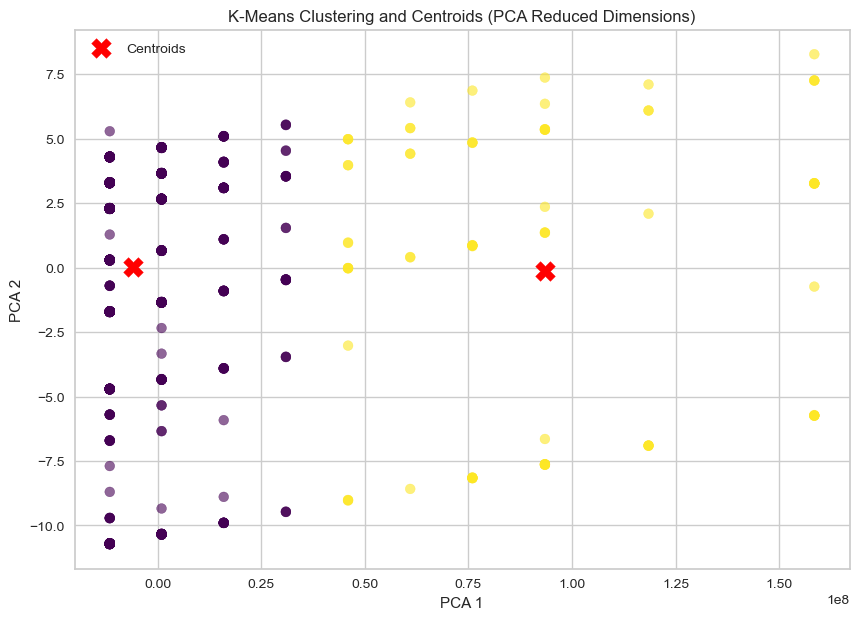

In [34]:


import matplotlib.pyplot as plt
# Reduce dimensions for visualization using PCA
pca = PCA(n_components=2)
principal_components = pca.fit_transform(df_final)

# Transform centroids using the same PCA model
pca_centroids = pca.transform(kmeans_centroids)

# Plot the data points
plt.figure(figsize=(10, 7))
plt.scatter(principal_components[:, 0], principal_components[:, 1], c=kmeans.labels_, cmap='viridis', s=50, alpha=0.6)

# Plot the centroids
plt.scatter(pca_centroids[:, 0], pca_centroids[:, 1], c='red', s=200, alpha=1, marker='X', label='Centroids')

plt.title('K-Means Clustering and Centroids (PCA Reduced Dimensions)')
plt.xlabel('PCA 1')
plt.ylabel('PCA 2')
plt.legend()
plt.grid(True)
plt.show()

In [ ]:
# ======================
# 🔹 Import Library
# ======================
import itertools
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler 


# ======================
# 🔹 Kelas Ant Colony Optimization
# ======================
class AntColonyOptimization:
    def __init__(self, data, n_clusters=2, n_ants=50, n_iterations=50,
                 alpha=1, beta=2, evaporation_rate=0.5):

        self.data = np.array(data)
        self.n_clusters = n_clusters
        self.n_ants = n_ants
        self.n_iterations = n_iterations
        self.alpha = alpha
        self.beta = beta
        self.evaporation_rate = evaporation_rate

        self.pheromone = np.ones((len(self.data), self.n_clusters))

    ##Fungsi Optimize##

    def optimize(self): 
        best_centroids = None
        best_score = -1

        for iteration in range(self.n_iterations): ##Looping iterasi ##
            all_centroids = []
            all_scores = []

            for _ in range(self.n_ants): ## untuk setiap semut
                centroids = self.select_centroids_probabilistic() ## memilih centroid ##
                score = self.evaluate_centroids(centroids) ## evaluasi ##

                all_centroids.append(centroids)
                all_scores.append(score)

                if score > best_score: ## Menyimpan hasil terbaik ##
                    best_centroids = centroids
                    best_score = score

            self.update_pheromone_batch(all_centroids, all_scores) ## update pheromone ##

        return best_centroids, best_score

    ## Pemilihan Centroid (ACO Core)
    def select_centroids_probabilistic(self):
        centroids = []
        remaining_indices = list(range(len(self.data))) ## ambil index data ##

        for cluster_idx in range(self.n_clusters): ## Untuk setiap cluster ##
            pheromone_values = self.pheromone[remaining_indices, cluster_idx] ## ambil pheromone ##

            if centroids:
                prev_centroids = np.array(centroids)
                distances = cdist(self.data[remaining_indices], prev_centroids).min(axis=1) ## Hitung jarak ##
            else:
                distances = np.ones(len(remaining_indices))

            heuristic = 1 / (distances + 1e-6)
            probs = (pheromone_values ** self.alpha) * (heuristic ** self.beta)  ## Hirung Probabilitas ##
            probs /= probs.sum()

            chosen_index = np.random.choice(remaining_indices, p=probs) ## Pilih Centroid ##
            centroids.append(self.data[chosen_index])
            remaining_indices.remove(chosen_index)

        return np.array(centroids)

    def evaluate_centroids(self, centroids): ## Evaluasi centroid (ACO Menentukan centroid , K-Means hanya refine)##
        try:
            kmeans = KMeans(
                n_clusters=self.n_clusters,
                init=centroids,
                n_init=1,
                random_state=42
            )
            kmeans.fit(self.data)

            if len(np.unique(kmeans.labels_)) > 1:
                return silhouette_score(self.data, kmeans.labels_)
            else:
                return -1
        except Exception:
            return -1

    def update_pheromone_batch(self, all_centroids, all_scores): ## Fungsi Update Pheromone ##
        self.pheromone *= (1 - self.evaporation_rate) ## Evaporasi (Menghitung jejak lama)##

        for centroids, score in zip(all_centroids, all_scores):
            if score > 0:
                for i, centroid in enumerate(centroids):
                    distances = np.linalg.norm(self.data - centroid, axis=1)
                    delta_pheromone = score / (distances + 1e-6)  ## Update berdasarkan solusi ##
                    self.pheromone[:, i] += delta_pheromone

        self.pheromone = np.clip(self.pheromone, 1e-6, None)

# ======================
# 🔹 Grid Search Parameter ACO
# ======================
param_grid = {
    'alpha': [1, 2],
    'beta': [2, 3],
    'evaporation_rate': [0.5, 0.7],
    'n_ants': [50, 100]
}

results = []
param_combinations = list(itertools.product(
    param_grid['alpha'],
    param_grid['beta'],
    param_grid['evaporation_rate'],
    param_grid['n_ants']
))

for alpha, beta, evap, n_ants in param_combinations:
    print(f"🧪 Running ACO | alpha={alpha}, beta={beta}, evap={evap}, ants={n_ants}")

    aco = AntColonyOptimization(
        df_final,
        n_clusters=2,
        alpha=alpha,
        beta=beta,
        evaporation_rate=evap,
        n_ants=n_ants,
        n_iterations=50
    )

    centroids, best_score = aco.optimize()

    results.append({
        'alpha': alpha,
        'beta': beta,
        'evaporation_rate': evap,
        'n_ants': n_ants,
        'best_score': best_score
    })

# ======================
# 🔹 Hasil Akhir
# ======================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='best_score', ascending=False).reset_index(drop=True)

print("\n📊 Hasil Perbandingan Parameter ACO:")
print(results_df)


🧪 Running ACO | alpha=1, beta=2, evap=0.5, ants=50
🧪 Running ACO | alpha=1, beta=2, evap=0.5, ants=100
🧪 Running ACO | alpha=1, beta=2, evap=0.7, ants=50
🧪 Running ACO | alpha=1, beta=2, evap=0.7, ants=100
🧪 Running ACO | alpha=1, beta=3, evap=0.5, ants=50
🧪 Running ACO | alpha=1, beta=3, evap=0.5, ants=100
🧪 Running ACO | alpha=1, beta=3, evap=0.7, ants=50
🧪 Running ACO | alpha=1, beta=3, evap=0.7, ants=100
🧪 Running ACO | alpha=2, beta=2, evap=0.5, ants=50
🧪 Running ACO | alpha=2, beta=2, evap=0.5, ants=100
🧪 Running ACO | alpha=2, beta=2, evap=0.7, ants=50
🧪 Running ACO | alpha=2, beta=2, evap=0.7, ants=100
🧪 Running ACO | alpha=2, beta=3, evap=0.5, ants=50
🧪 Running ACO | alpha=2, beta=3, evap=0.5, ants=100
🧪 Running ACO | alpha=2, beta=3, evap=0.7, ants=50
🧪 Running ACO | alpha=2, beta=3, evap=0.7, ants=100

📊 Hasil Perbandingan Parameter ACO:
    alpha  beta  evaporation_rate  n_ants  best_score
0       1     2               0.5      50    0.890738
1       1     2               0

c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


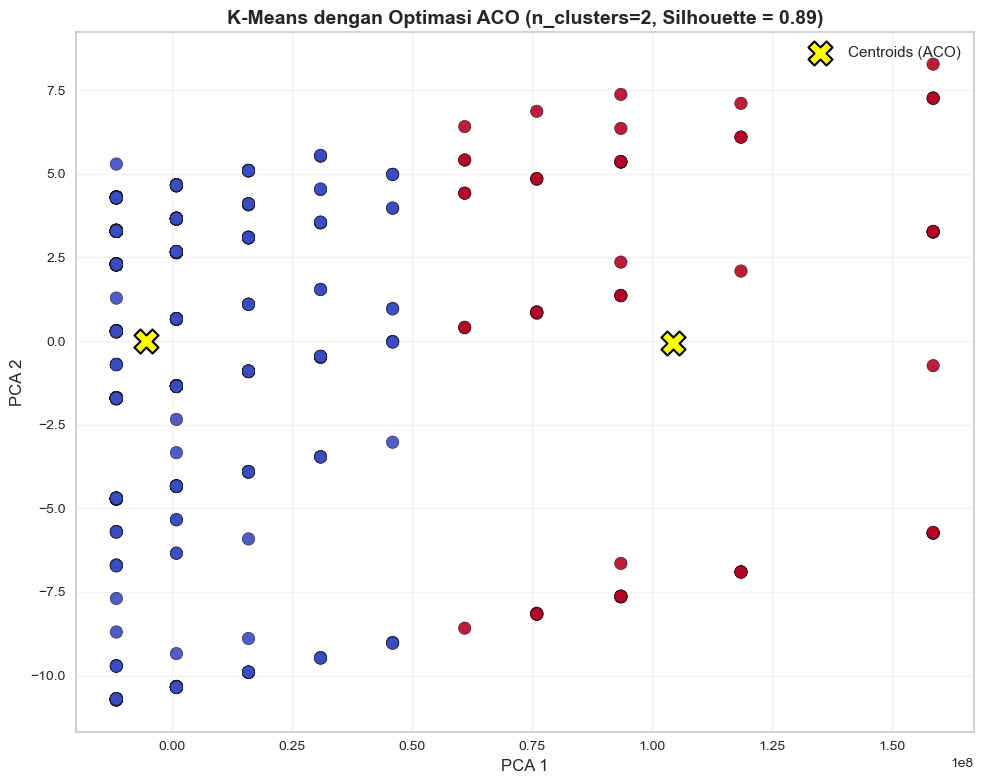

In [36]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- Reduksi dimensi ke 2D untuk visualisasi ---
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_final)

# --- Ambil parameter terbaik hasil grid search ---
best_params = results_df.iloc[0]

# --- Jalankan ACO ulang dengan parameter terbaik ---
aco_best = AntColonyOptimization(
    df_final,
    n_clusters=2,
    alpha=best_params['alpha'],
    beta=best_params['beta'],
    evaporation_rate=best_params['evaporation_rate'],
    n_ants=int(best_params['n_ants']),
    n_iterations=50
)

# --- Optimasi centroid menggunakan ACO ---
optimal_centroids, best_score_aco = aco_best.optimize()

# --- Jalankan K-Means dengan centroid hasil ACO ---
kmeans_aco = KMeans(
    n_clusters=2,
    init=optimal_centroids,
    n_init=1,
    max_iter=300,
    random_state=42
)
kmeans_aco.fit(df_final)
labels_aco = kmeans_aco.labels_
silhouette_aco = silhouette_score(df_final, labels_aco)

# --- Transformasi centroid ke ruang PCA ---
centroids_aco_pca = pca.transform(kmeans_aco.cluster_centers_)

# --- Visualisasi hasil clustering ---
plt.figure(figsize=(10, 8))

# Scatter data dengan warna kontras dan titik besar
plt.scatter(
    df_pca[:, 0],
    df_pca[:, 1],
    c=labels_aco,
    cmap='coolwarm',   # Warna kontras (bagus untuk 2 cluster)
    s=80,              # Ukuran titik
    alpha=0.9,         # Transparansi ringan
    edgecolor='k',     # Garis tepi hitam agar cluster terlihat jelas
    linewidth=0.4
)

# Plot centroid hasil ACO
plt.scatter(
    centroids_aco_pca[:, 0],
    centroids_aco_pca[:, 1],
    c='yellow',
    marker='X',
    s=300,
    edgecolor='black',
    linewidth=1.5,
    label='Centroids (ACO)'
)

# --- Label dan tampilan ---
plt.title(f"K-Means dengan Optimasi ACO (n_clusters=2, Silhouette = {silhouette_aco:.2f})",
          fontsize=14, weight='bold')
plt.xlabel("PCA 1", fontsize=12)
plt.ylabel("PCA 2", fontsize=12)
plt.legend(fontsize=11, loc='upper right')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# K-MEANS&ACO Cluster = 3


In [37]:
# Jalankan K-Means biasa dan simpan centroidnya
kmeans = KMeans(n_clusters=3, random_state=42)
kmeans.fit(df_final)
labels = kmeans.labels_
silhouette_kmeans = silhouette_score(df_final, kmeans.labels_)
kmeans_centroids = kmeans.cluster_centers_
kmeans_centroids


array([[8.17649610e+06, 1.06166522e+01, 1.63573287e+00, 1.36860364e+00,
        7.29401561e-01, 8.02254987e-01, 3.03555941e-02, 6.67823070e-02,
        1.68256722e-01, 2.69731136e-01, 2.77536860e-01, 6.21856028e-01,
        7.45880312e-01],
       [1.26853448e+08, 6.75862069e+00, 1.89655172e+00, 1.32758621e+00,
        4.13793103e-01, 8.10344828e-01, 1.20689655e-01, 1.55172414e-01,
        2.75862069e-01, 4.65517241e-01, 4.31034483e-01, 4.82758621e-01,
        6.72413793e-01],
       [4.24600000e+07, 9.77600000e+00, 1.70400000e+00, 1.64000000e+00,
        7.76000000e-01, 7.04000000e-01, 4.80000000e-02, 8.80000000e-02,
        2.72000000e-01, 3.36000000e-01, 2.88000000e-01, 5.92000000e-01,
        6.08000000e-01]])

In [38]:
silhouette_kmeans

0.8052053996760237

c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


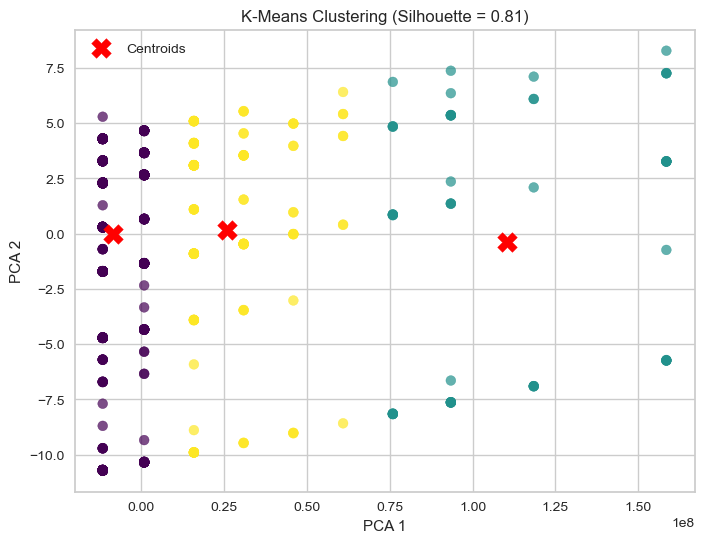

In [39]:
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_final)

# --- Visualisasi cluster ---
plt.figure(figsize=(8,6))
plt.scatter(df_pca[:, 0], df_pca[:, 1], c=labels, cmap='viridis', s=50, alpha=0.7)

# --- Visualisasi centroid (turunkan ke PCA juga) ---
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(centroids_pca[:, 0], centroids_pca[:, 1], c='red', marker='X', s=200, label='Centroids')

plt.title(f"K-Means Clustering (Silhouette = {silhouette_kmeans:.2f})")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.legend()
plt.show()

In [40]:
# ======================
# 🔹 Import Library
# ======================
import itertools
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler


# ======================
# 🔹 Kelas Ant Colony Optimization
# ======================
class AntColonyOptimization:
    def __init__(self, data, n_clusters=2, n_ants=50, n_iterations=50,
                 alpha=1, beta=2, evaporation_rate=0.5):

        self.data = np.array(data)
        self.n_clusters = n_clusters
        self.n_ants = n_ants
        self.n_iterations = n_iterations
        self.alpha = alpha
        self.beta = beta
        self.evaporation_rate = evaporation_rate

        self.pheromone = np.ones((len(self.data), self.n_clusters))

    def optimize(self):
        best_centroids = None
        best_score = -1

        for iteration in range(self.n_iterations):
            all_centroids = []
            all_scores = []

            for _ in range(self.n_ants):
                centroids = self.select_centroids_probabilistic()
                score = self.evaluate_centroids(centroids)

                all_centroids.append(centroids)
                all_scores.append(score)

                if score > best_score:
                    best_centroids = centroids
                    best_score = score

            self.update_pheromone_batch(all_centroids, all_scores)

        return best_centroids, best_score

    def select_centroids_probabilistic(self):
        centroids = []
        remaining_indices = list(range(len(self.data)))

        for cluster_idx in range(self.n_clusters):
            pheromone_values = self.pheromone[remaining_indices, cluster_idx]

            if centroids:
                prev_centroids = np.array(centroids)
                distances = cdist(self.data[remaining_indices], prev_centroids).min(axis=1)
            else:
                distances = np.ones(len(remaining_indices))

            heuristic = 1 / (distances + 1e-6)
            probs = (pheromone_values ** self.alpha) * (heuristic ** self.beta)
            probs /= probs.sum()

            chosen_index = np.random.choice(remaining_indices, p=probs)
            centroids.append(self.data[chosen_index])
            remaining_indices.remove(chosen_index)

        return np.array(centroids)

    def evaluate_centroids(self, centroids):
        try:
            kmeans = KMeans(
                n_clusters=self.n_clusters,
                init=centroids,
                n_init=1,
                random_state=42
            )
            kmeans.fit(self.data)

            if len(np.unique(kmeans.labels_)) > 1:
                return silhouette_score(self.data, kmeans.labels_)
            else:
                return -1
        except Exception:
            return -1

    def update_pheromone_batch(self, all_centroids, all_scores):
        self.pheromone *= (1 - self.evaporation_rate)

        for centroids, score in zip(all_centroids, all_scores):
            if score > 0:
                for i, centroid in enumerate(centroids):
                    distances = np.linalg.norm(self.data - centroid, axis=1)
                    delta_pheromone = score / (distances + 1e-6)
                    self.pheromone[:, i] += delta_pheromone

        self.pheromone = np.clip(self.pheromone, 1e-6, None)

# ======================
# 🔹 Grid Search Parameter ACO
# ======================
param_grid = {
    'alpha': [1, 2],
    'beta': [2, 3],
    'evaporation_rate': [0.5, 0.7],
    'n_ants': [50, 100]
}

results = []
param_combinations = list(itertools.product(
    param_grid['alpha'],
    param_grid['beta'],
    param_grid['evaporation_rate'],
    param_grid['n_ants']
))

for alpha, beta, evap, n_ants in param_combinations:
    print(f"🧪 Running ACO | alpha={alpha}, beta={beta}, evap={evap}, ants={n_ants}")

    aco = AntColonyOptimization(
        df_final,
        n_clusters=3,
        alpha=alpha,
        beta=beta,
        evaporation_rate=evap,
        n_ants=n_ants,
        n_iterations=50
    )

    centroids, best_score = aco.optimize()

    results.append({
        'alpha': alpha,
        'beta': beta,
        'evaporation_rate': evap,
        'n_ants': n_ants,
        'best_score': best_score
    })

# ======================
# 🔹 Hasil Akhir
# ======================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='best_score', ascending=False).reset_index(drop=True)

print("\n📊 Hasil Perbandingan Parameter ACO:")
print(results_df)


🧪 Running ACO | alpha=1, beta=2, evap=0.5, ants=50
🧪 Running ACO | alpha=1, beta=2, evap=0.5, ants=100
🧪 Running ACO | alpha=1, beta=2, evap=0.7, ants=50
🧪 Running ACO | alpha=1, beta=2, evap=0.7, ants=100
🧪 Running ACO | alpha=1, beta=3, evap=0.5, ants=50
🧪 Running ACO | alpha=1, beta=3, evap=0.5, ants=100
🧪 Running ACO | alpha=1, beta=3, evap=0.7, ants=50
🧪 Running ACO | alpha=1, beta=3, evap=0.7, ants=100
🧪 Running ACO | alpha=2, beta=2, evap=0.5, ants=50
🧪 Running ACO | alpha=2, beta=2, evap=0.5, ants=100
🧪 Running ACO | alpha=2, beta=2, evap=0.7, ants=50
🧪 Running ACO | alpha=2, beta=2, evap=0.7, ants=100
🧪 Running ACO | alpha=2, beta=3, evap=0.5, ants=50
🧪 Running ACO | alpha=2, beta=3, evap=0.5, ants=100
🧪 Running ACO | alpha=2, beta=3, evap=0.7, ants=50
🧪 Running ACO | alpha=2, beta=3, evap=0.7, ants=100

📊 Hasil Perbandingan Parameter ACO:
    alpha  beta  evaporation_rate  n_ants  best_score
0       1     2               0.5      50    0.862616
1       1     2               0

c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


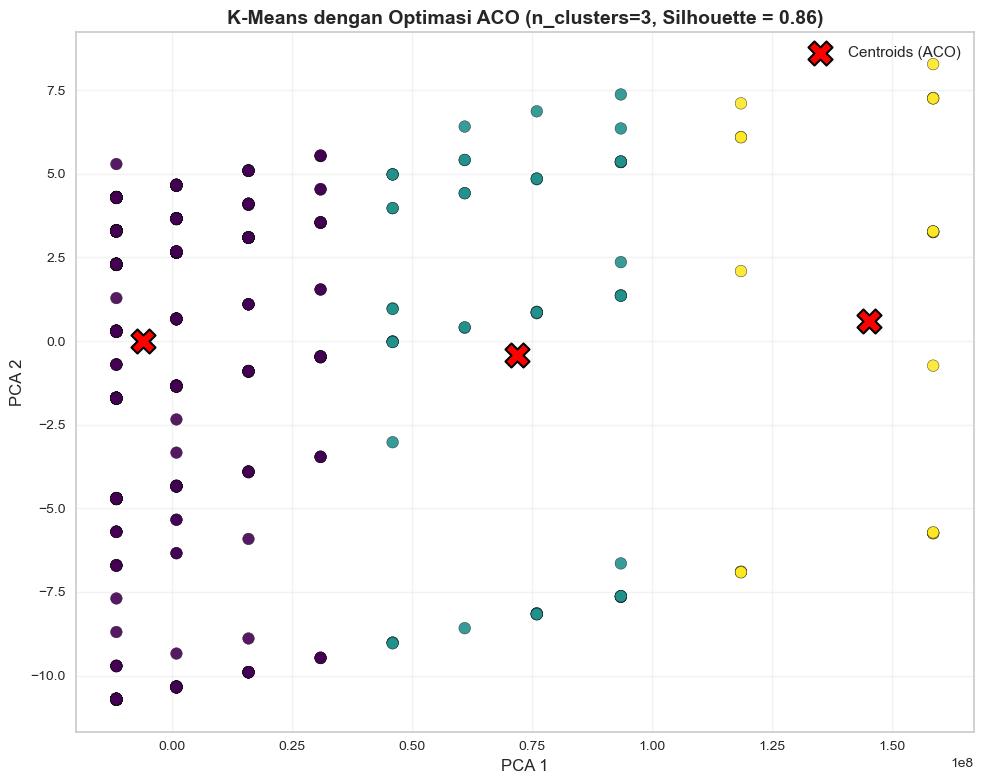

In [41]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- Reduksi dimensi untuk visualisasi ---
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_final)

# --- Ambil parameter terbaik dari hasil grid search ---
best_params = results_df.iloc[0]

# --- Jalankan ACO ulang dengan parameter terbaik ---
aco_best = AntColonyOptimization(
    df_final,
    n_clusters=3,
    alpha=best_params['alpha'],
    beta=best_params['beta'],
    evaporation_rate=best_params['evaporation_rate'],
    n_ants=int(best_params['n_ants']),
    n_iterations=50
)

# --- Optimasi centroid menggunakan ACO ---
optimal_centroids, best_score_aco = aco_best.optimize()

# --- Jalankan K-Means dengan centroid hasil ACO ---
kmeans_aco = KMeans(n_clusters=3, init=optimal_centroids, n_init=1, max_iter=300, random_state=42)
kmeans_aco.fit(df_final)
labels_aco = kmeans_aco.labels_
silhouette_aco = silhouette_score(df_final, labels_aco)

# --- Transformasi centroid ke ruang PCA ---
centroids_aco_pca = pca.transform(kmeans_aco.cluster_centers_)

# --- Visualisasi hasil clustering ---
plt.figure(figsize=(10, 8))

# Titik data klaster (lebih besar dan berwarna kontras)
plt.scatter(
    df_pca[:, 0],
    df_pca[:, 1],
    c=labels_aco,
    cmap='viridis',    # Warna kontras antar cluster
    s=70,              # Ukuran titik
    alpha=0.9,         # Transparansi pas
    edgecolor='k',     # Garis tepi hitam biar jelas
    linewidth=0.3
)

# Titik centroid hasil ACO
plt.scatter(
    centroids_aco_pca[:, 0],
    centroids_aco_pca[:, 1],
    c='red',
    marker='X',
    s=300,
    edgecolor='black',
    linewidth=1.5,
    label='Centroids (ACO)'
)

# --- Label dan tampilan plot ---
plt.title(f"K-Means dengan Optimasi ACO (n_clusters=3, Silhouette = {silhouette_aco:.2f})",
          fontsize=14, weight='bold')
plt.xlabel("PCA 1", fontsize=12)
plt.ylabel("PCA 2", fontsize=12)
plt.legend(fontsize=11, loc='upper right')
plt.grid(alpha=0.25)
plt.tight_layout()
plt.show()


# k-MEANS&ACO Cluster = 4


In [42]:
# Jalankan K-Means biasa dan simpan centroidnya
kmeans = KMeans(n_clusters=4, random_state=42)
kmeans.fit(df_final)
labels = kmeans.labels_
silhouette_kmeans = silhouette_score(df_final, kmeans.labels_)
kmeans_centroids = kmeans.cluster_centers_
kmeans_centroids


array([[8.17649610e+06, 1.06166522e+01, 1.63573287e+00, 1.36860364e+00,
        7.29401561e-01, 8.02254987e-01, 3.03555941e-02, 6.67823070e-02,
        1.68256722e-01, 2.69731136e-01, 2.77536860e-01, 6.21856028e-01,
        7.45880312e-01],
       [1.03550000e+08, 7.34000000e+00, 2.06000000e+00, 1.38000000e+00,
        4.60000000e-01, 8.20000000e-01, 1.20000000e-01, 1.60000000e-01,
        2.80000000e-01, 5.40000000e-01, 4.40000000e-01, 3.80000000e-01,
        7.00000000e-01],
       [4.00641026e+07, 9.70085470e+00, 1.64102564e+00, 1.64957265e+00,
        7.94871795e-01, 7.09401709e-01, 4.27350427e-02, 8.54700855e-02,
        2.73504274e-01, 3.07692308e-01, 2.82051282e-01, 6.23931624e-01,
        5.98290598e-01],
       [1.75000000e+08, 7.00000000e+00, 1.75000000e+00, 1.25000000e+00,
        3.12500000e-01, 6.87500000e-01, 1.25000000e-01, 1.25000000e-01,
        2.50000000e-01, 3.75000000e-01, 3.75000000e-01, 6.25000000e-01,
        6.25000000e-01]])

In [43]:
silhouette_kmeans

0.8055818878897497

c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


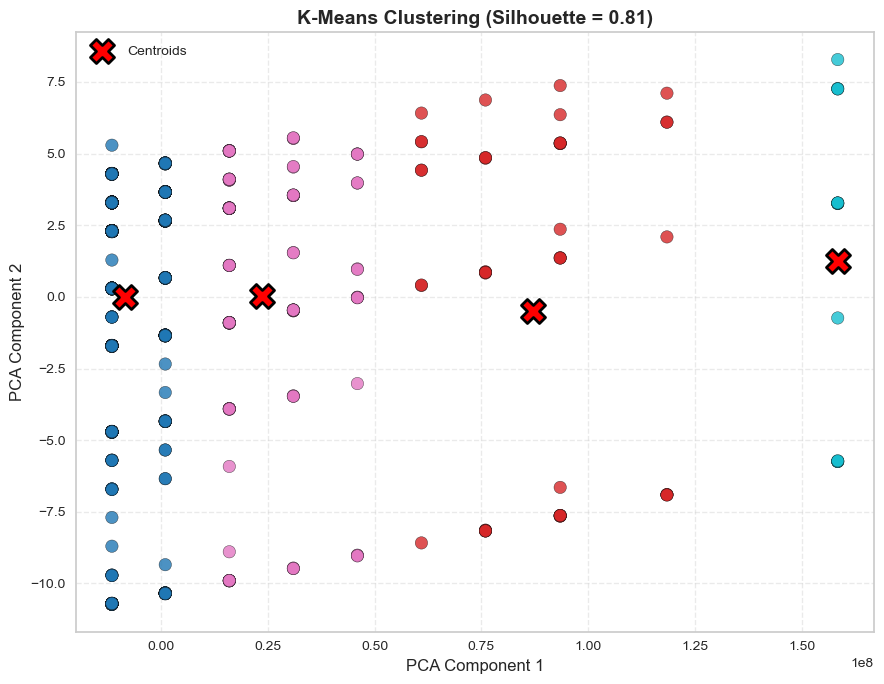

In [44]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA

# --- Reduksi dimensi ke 2 komponen PCA ---
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_final)

# --- Visualisasi cluster ---
plt.figure(figsize=(9,7))
plt.scatter(
    df_pca[:, 0], df_pca[:, 1],
    c=labels,
    cmap='tab10',          # 🎨 Ganti warna agar lebih kontras dan tanpa kuning
    s=80,                  # 🔹 Perbesar ukuran titik
    edgecolor='k',         # 🔹 Tambahkan outline hitam agar jelas
    alpha=0.8              # 🔹 Sedikit transparan
)

# --- Visualisasi centroid (turunkan ke PCA juga) ---
centroids_pca = pca.transform(kmeans.cluster_centers_)
plt.scatter(
    centroids_pca[:, 0],
    centroids_pca[:, 1],
    c='red',
    marker='X',
    s=300,
    edgecolor='black',
    linewidth=2,
    label='Centroids'
)

# # --- Label untuk tiap centroid ---
# for i, (x, y) in enumerate(centroids_pca):
#     plt.text(x, y, f'C{i}', color='white', fontsize=10,
#              ha='center', va='center', fontweight='bold')

# --- Hiasan tambahan ---
plt.title(f"K-Means Clustering (Silhouette = {silhouette_kmeans:.2f})", fontsize=14, fontweight='bold')
plt.xlabel("PCA Component 1", fontsize=12)
plt.ylabel("PCA Component 2", fontsize=12)
plt.legend(fontsize=10)
plt.grid(True, linestyle='--', alpha=0.4)
plt.tight_layout()
plt.show()


In [45]:
# ======================
# 🔹 Import Library
# ======================
import itertools
import numpy as np
import pandas as pd
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from scipy.spatial.distance import cdist
from sklearn.preprocessing import StandardScaler


# ======================
# 🔹 Kelas Ant Colony Optimization
# ======================
class AntColonyOptimization:
    def __init__(self, data, n_clusters=2, n_ants=50, n_iterations=50,
                 alpha=1, beta=2, evaporation_rate=0.5):

        self.data = np.array(data)
        self.n_clusters = n_clusters
        self.n_ants = n_ants
        self.n_iterations = n_iterations
        self.alpha = alpha
        self.beta = beta
        self.evaporation_rate = evaporation_rate

        self.pheromone = np.ones((len(self.data), self.n_clusters))

    def optimize(self):
        best_centroids = None
        best_score = -1

        for iteration in range(self.n_iterations):
            all_centroids = []
            all_scores = []

            for _ in range(self.n_ants):
                centroids = self.select_centroids_probabilistic()
                score = self.evaluate_centroids(centroids)

                all_centroids.append(centroids)
                all_scores.append(score)

                if score > best_score:
                    best_centroids = centroids
                    best_score = score

            self.update_pheromone_batch(all_centroids, all_scores)

        return best_centroids, best_score

    def select_centroids_probabilistic(self):
        centroids = []
        remaining_indices = list(range(len(self.data)))

        for cluster_idx in range(self.n_clusters):
            pheromone_values = self.pheromone[remaining_indices, cluster_idx]

            if centroids:
                prev_centroids = np.array(centroids)
                distances = cdist(self.data[remaining_indices], prev_centroids).min(axis=1)
            else:
                distances = np.ones(len(remaining_indices))

            heuristic = 1 / (distances + 1e-6)
            probs = (pheromone_values ** self.alpha) * (heuristic ** self.beta)
            probs /= probs.sum()

            chosen_index = np.random.choice(remaining_indices, p=probs)
            centroids.append(self.data[chosen_index])
            remaining_indices.remove(chosen_index)

        return np.array(centroids)

    def evaluate_centroids(self, centroids):
        try:
            kmeans = KMeans(
                n_clusters=self.n_clusters,
                init=centroids,
                n_init=1,
                random_state=42
            )
            kmeans.fit(self.data)

            if len(np.unique(kmeans.labels_)) > 1:
                return silhouette_score(self.data, kmeans.labels_)
            else:
                return -1
        except Exception:
            return -1

    def update_pheromone_batch(self, all_centroids, all_scores):
        self.pheromone *= (1 - self.evaporation_rate)

        for centroids, score in zip(all_centroids, all_scores):
            if score > 0:
                for i, centroid in enumerate(centroids):
                    distances = np.linalg.norm(self.data - centroid, axis=1)
                    delta_pheromone = score / (distances + 1e-6)
                    self.pheromone[:, i] += delta_pheromone

        self.pheromone = np.clip(self.pheromone, 1e-6, None)

# ======================
# 🔹 Grid Search Parameter ACO
# ======================
param_grid = {
    'alpha': [1, 2],
    'beta': [2, 3],
    'evaporation_rate': [0.5, 0.7],
    'n_ants': [50, 100]
}

results = []
param_combinations = list(itertools.product(
    param_grid['alpha'],
    param_grid['beta'],
    param_grid['evaporation_rate'],
    param_grid['n_ants']
))

for alpha, beta, evap, n_ants in param_combinations:
    print(f"🧪 Running ACO | alpha={alpha}, beta={beta}, evap={evap}, ants={n_ants}")

    aco = AntColonyOptimization(
        df_final,
        n_clusters=4,
        alpha=alpha,
        beta=beta,
        evaporation_rate=evap,
        n_ants=n_ants,
        n_iterations=50
    )

    centroids, best_score = aco.optimize()

    results.append({
        'alpha': alpha,
        'beta': beta,
        'evaporation_rate': evap,
        'n_ants': n_ants,
        'best_score': best_score
    })

# ======================
# 🔹 Hasil Akhir
# ======================
results_df = pd.DataFrame(results)
results_df = results_df.sort_values(by='best_score', ascending=False).reset_index(drop=True)

print("\n📊 Hasil Perbandingan Parameter ACO:")
print(results_df)


🧪 Running ACO | alpha=1, beta=2, evap=0.5, ants=50
🧪 Running ACO | alpha=1, beta=2, evap=0.5, ants=100
🧪 Running ACO | alpha=1, beta=2, evap=0.7, ants=50
🧪 Running ACO | alpha=1, beta=2, evap=0.7, ants=100
🧪 Running ACO | alpha=1, beta=3, evap=0.5, ants=50
🧪 Running ACO | alpha=1, beta=3, evap=0.5, ants=100
🧪 Running ACO | alpha=1, beta=3, evap=0.7, ants=50
🧪 Running ACO | alpha=1, beta=3, evap=0.7, ants=100
🧪 Running ACO | alpha=2, beta=2, evap=0.5, ants=50
🧪 Running ACO | alpha=2, beta=2, evap=0.5, ants=100
🧪 Running ACO | alpha=2, beta=2, evap=0.7, ants=50
🧪 Running ACO | alpha=2, beta=2, evap=0.7, ants=100
🧪 Running ACO | alpha=2, beta=3, evap=0.5, ants=50
🧪 Running ACO | alpha=2, beta=3, evap=0.5, ants=100
🧪 Running ACO | alpha=2, beta=3, evap=0.7, ants=50
🧪 Running ACO | alpha=2, beta=3, evap=0.7, ants=100

📊 Hasil Perbandingan Parameter ACO:
    alpha  beta  evaporation_rate  n_ants  best_score
0       1     2               0.7     100    0.924704
1       1     3               0

c:\Users\ASUS\anaconda3\Lib\site-packages\sklearn\utils\validation.py:2739: UserWarning: X does not have valid feature names, but PCA was fitted with feature names
  warnings.warn(


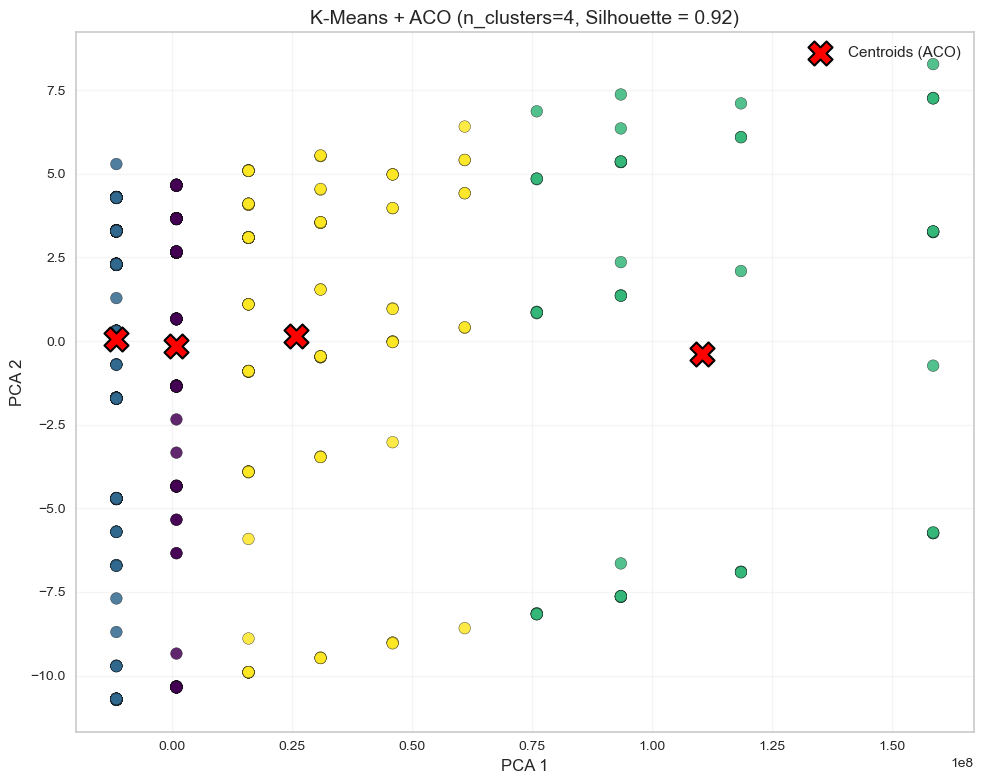

In [46]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

# --- PCA ke 2 dimensi ---
pca = PCA(n_components=2)
df_pca = pca.fit_transform(df_final)

# --- Ambil parameter terbaik hasil grid search ---
best_params = results_df.iloc[0]  # misal baris pertama adalah hasil terbaik

# --- Jalankan ACO ulang dengan parameter terbaik ---
aco_best = AntColonyOptimization(
    df_final,
    n_clusters=4,
    alpha=best_params['alpha'],
    beta=best_params['beta'],
    evaporation_rate=best_params['evaporation_rate'],
    n_ants=int(best_params['n_ants']),
    n_iterations=50
)

optimal_centroids, best_score_aco = aco_best.optimize()

# --- Jalankan K-Means dengan centroid hasil ACO ---
kmeans_aco = KMeans(n_clusters=4, init=optimal_centroids, n_init=1, max_iter=300)
kmeans_aco.fit(df_final)
labels_aco = kmeans_aco.labels_
silhouette_aco = silhouette_score(df_final, labels_aco)

# --- Transformasi centroid ke ruang PCA untuk visualisasi ---
centroids_aco_pca = pca.transform(kmeans_aco.cluster_centers_)

# --- Visualisasi ---
plt.figure(figsize=(10, 8))

# Warna cluster dengan alpha lebih kecil agar titik lebih “ringan” dilihat
plt.scatter(
    df_pca[:, 0],
    df_pca[:, 1],
    c=labels_aco,
    cmap='viridis',    # Warna lebih jelas antar cluster
    s=70,              # Ukuran titik sedikit lebih besar agar padat
    alpha=0.85,        # Transparansi untuk efek lembut
    edgecolor='k',     # Garis tepi hitam biar kontras
    linewidth=0.3
)

# Plot centroid dengan simbol besar dan jelas
plt.scatter(
    centroids_aco_pca[:, 0],
    centroids_aco_pca[:, 1],
    c='red',
    marker='X',
    s=300,
    label='Centroids (ACO)',
    edgecolor='black',
    linewidth=1.5
)

plt.title(f"K-Means + ACO (n_clusters=4, Silhouette = {silhouette_aco:.2f})", fontsize=14)
plt.xlabel("PCA 1", fontsize=12)
plt.ylabel("PCA 2", fontsize=12)
plt.legend(fontsize=11, loc='upper right')
plt.grid(alpha=0.2)
plt.tight_layout()
plt.show()


In [47]:
# # --- Ambil parameter terbaik dari hasil grid search ---
# best_params = results_df.iloc[0]  # Baris pertama = best_score tertinggi

# # --- Jalankan ACO ulang dengan parameter terbaik ---
# aco_best = AntColonyOptimization(
#     df_final,
#     n_clusters=4,
#     alpha=best_params['alpha'],
#     beta=best_params['beta'],
#     evaporation_rate=best_params['evaporation_rate'],
#     n_ants=int(best_params['n_ants']),
#     n_iterations=50
# )

# optimal_centroids, best_score_aco = aco_best.optimize()

# # --- Jalankan K-Means dengan centroid hasil ACO ---
# kmeans_aco = KMeans(n_clusters=4, init=optimal_centroids, n_init=1, max_iter=300, random_state=42)
# kmeans_aco.fit(df_final)

# # Simpan label cluster untuk tiap data
# df_final['Cluster'] = kmeans_aco.labels_


In [48]:
# # Add the cluster labels to the DataFrame
# df_final['Cluster'] = kmeans_aco.labels_

# # Save the DataFrame to a CSV file
# df_final.to_excel('df_final_clustered_aco_4.xlsx', index=False)

# # Download the file
# from google.colab import files
# files.download('df_final_clustered_aco_4.xlsx')

# Grafik Perbandingan

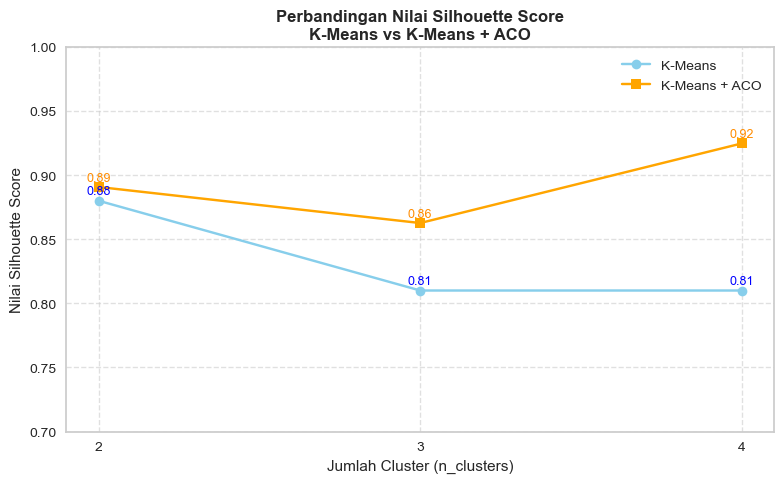

In [53]:
import matplotlib.pyplot as plt

n_clusters = [2, 3, 4]
silhouette_aco = [0.890738, 0.862616, 0.924704]
silhouette_kmeans = [0.88, 0.81, 0.81]

# Plot line chart
plt.figure(figsize=(8, 5))
plt.plot(n_clusters, silhouette_kmeans, marker='o', linestyle='-', color='skyblue', label='K-Means')
plt.plot(n_clusters, silhouette_aco, marker='s', linestyle='-', color='orange', label='K-Means + ACO')

# Tambahkan nilai di setiap titik
for x, y in zip(n_clusters, silhouette_kmeans):
    plt.text(x, y + 0.005, f'{y:.2f}', ha='center', color='blue', fontsize=9)
for x, y in zip(n_clusters, silhouette_aco):
    plt.text(x, y + 0.005, f'{y:.2f}', ha='center', color='darkorange', fontsize=9)

# Label dan tampilan
plt.title('Perbandingan Nilai Silhouette Score\nK-Means vs K-Means + ACO', fontsize=12, fontweight='bold')
plt.xlabel('Jumlah Cluster (n_clusters)')
plt.ylabel('Nilai Silhouette Score')
plt.xticks(n_clusters)
plt.ylim(0.7, 1.0)
plt.grid(True, linestyle='--', alpha=0.6)
plt.legend()

# Tampilkan
plt.tight_layout()
plt.show()

## **Save Dataset Preprocessing**

In [50]:
# # Save the DataFrame to a CSV file
# df_final.to_csv('df_final.csv', index=False)

# # Download the file
# from google.colab import files
# files.download('df_final.csv')